In [18]:
import numpy as np
import pandas as pd
import sys
import matplotlib.pyplot as plt
import math
sys.path.append('../../')
from Scattering_Simulator import pairwise_method
from Scattering_Simulator import Read_PDB
from genetic_algorithm import GA_functions as GA
from genetic_algorithm import curve_fitting as cf
from scipy import integrate
import torch

In [19]:
q = np.geomspace(0.1, 1, 3000)
R = 5
F_sphere = 3*(np.sin(q*R) - q*R*np.cos(q*R))/(q*R)**3

In [20]:
I_monomer = F_sphere**2
x = 2*R
I_dimer = F_sphere**2*(2 + 2*np.sin(q*x)/(q*x))
x = 2*R
I_triplet = F_sphere**2*(3 + 6*np.sin(q*x)/(q*x))
x = 2*R
I_tetrahedral = F_sphere**2*(4 + 12*np.sin(q*x)/(q*x))
x = 2*R
I_dipyramid = F_sphere**2*(5 + 18*np.sin(q*x)/(q*x) + 2*(np.sin(np.sqrt(8/3)*q*x)/(np.sqrt(8/3)*q*x)))

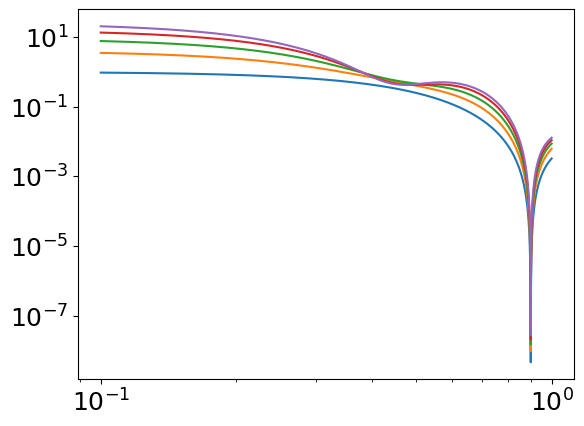

In [21]:
plt.loglog(q, I_monomer)
plt.loglog(q, I_dimer)
plt.loglog(q, I_triplet)
plt.loglog(q, I_tetrahedral)
plt.loglog(q, I_dipyramid)

In [22]:
# Imports required for the MC‑DFM simulations
import sys
sys.path.append('../')
from Scattering_Simulator import pairwise_method
from Scattering_Simulator import fitting
from Scattering_Simulator import Read_PDB
from mpl_toolkits.mplot3d import axes3d
import matplotlib.pyplot as plt
import numpy as np

# --------------------------------------------------------------
# Helper: generate random coordinates for a solid sphere
# --------------------------------------------------------------
def generate_sphere_coords(diameter, n_points):
    """
    Generate random points uniformly distributed inside a solid sphere.
    The 4th column contains a dummy SLD value (chosen as 1.0).
    """
    R = diameter / 2.0                            # sphere radius
    # random radius sampling (cubic root preserves volume)
    u = np.random.rand(n_points)
    r = R * np.cbrt(u)
    # random direction (uniform on the sphere)
    cos_theta = 1 - 2 * np.random.rand(n_points)
    theta = np.arccos(cos_theta)
    phi = 2 * np.pi * np.random.rand(n_points)
    # Cartesian coordinates
    x = r * np.sin(theta) * np.cos(phi)
    y = r * np.sin(theta) * np.sin(phi)
    z = r * np.cos(theta)
    sld = np.ones_like(x)  # dummy SLD difference
    coordinates = np.column_stack((x, y, z, sld))
    return coordinates

# --------------------------------------------------------------
# Build the basic building block (monomer) – a 10 nm sphere
# --------------------------------------------------------------
diameter_nm   = 10.0
n_points     = 200000                 # number of sampling points for the sphere
sphere_coords = generate_sphere_coords(diameter_nm, n_points)  # shape (n_points, 4)

# --------------------------------------------------------------
# Define the lattice coordinates (translations & rotations) for each assembly
# --------------------------------------------------------------
d = diameter_nm  # side length of the equilateral triangle

# Helper to create 6‑column lattice array [tx, ty, tz, rx, ry, rz]
def lattice_array(translations):
    """
    translations: list of [x, y, z] relative positions
    returns: (N,6) array where rotations are all zeros
    """
    return np.column_stack([np.array(translations), np.zeros((len(translations), 3))])

# 1. Monomer (single sphere)
lattice_monomer = lattice_array([[0, 0, 0]])

# 2. Dimer – two spheres separated by 10 nm along x
lattice_dimer = lattice_array([[0, 0, 0], [d, 0, 0]])

# 3. Triplet – equilateral triangle in the xy‑plane
lattice_triplet = lattice_array([
    [0, 0, 0],
    [d, 0, 0],
    [d/2, d*np.sqrt(3)/2, 0]
])

# 4. Tetrahedral – triangle base + one sphere above the centroid
h = d * np.sqrt(2/3)                                 # vertical offset for non‑overlap
centroid_xy = np.array([d/2, d*np.sqrt(3)/6])        # centroid of the base triangle
lattice_tetra = lattice_array([
    [0, 0, 0],
    [d, 0, 0],
    [d/2, d*np.sqrt(3)/2, 0],
    [centroid_xy[0], centroid_xy[1], h]
])

# 5. Trigonal dipyramidal – tetrahedral + one sphere mirrored below the base
lattice_dipyramid = lattice_array([
    [0, 0, 0],
    [d, 0, 0],
    [d/2, d*np.sqrt(3)/2, 0],
    [centroid_xy[0], centroid_xy[1], h],
    [centroid_xy[0], centroid_xy[1], -h]
])

# --------------------------------------------------------------
# Simulation parameters
# --------------------------------------------------------------
n_pairwise = 10000000          # fixed for MC‑DFM
histogram_bins = 10000
q = np.geomspace(0.1, 1, 3000)  # q‑grid for all calculations

# Helper to simulate one assembly and return a scaled intensity
def simulate_assembly(lattice_coords, label=None):
    """
    Runs MC‑DFM simulation for the given lattice coordinates,
    computes the invariant, scales the intensity,
    and returns the scaled I(q).
    """
    # Simulate scattering for the lattice
    Iq_raw = fitting.simulate_scattering_lattice(
        sphere_coords, lattice_coords, q, histogram_bins, n_pairwise, mode='single'
    )
    # Scalar invariant (intensity integrated over q)
    invariant = fitting.invariant(np.column_stack((q, Iq_raw)))
    # Number of sub‑units in this assembly
    N_sub = lattice_coords.shape[0]
    # Equal proportion of each assembly -> 1/5
    prop = 0.2
    # Scale intensity according to invariant and number of sub‑units
    Iq_scaled = fitting.scale_intensity(Iq_raw, invariant, N_sub, prop)

    return Iq_scaled

# --------------------------------------------------------------
# Simulate each assembly
# --------------------------------------------------------------
Iq_monomer    = simulate_assembly(lattice_monomer)
Iq_dimer      = simulate_assembly(lattice_dimer)
Iq_triplet    = simulate_assembly(lattice_triplet)
Iq_tetrahedral = simulate_assembly(lattice_tetra)
Iq_dipyramid  = simulate_assembly(lattice_dipyramid)

# --------------------------------------------------------------
# Total scattering (sum of all scaled assemblies)
# --------------------------------------------------------------
Iq_total = Iq_monomer + Iq_dimer + Iq_triplet + Iq_tetrahedral + Iq_dipyramid

# --------------------------------------------------------------
# Plotting the final scattering curve
# --------------------------------------------------------------
#fitting.plot_intensity(q, Iq_total)
# Optional: visualize the final structure of all assemblies together
# fitting.plot_structure_lattice(sphere_coords, lattice_dipyramid, 1000000)

Text(0.5, 0, 'q ($\\AA^{-1}$)')

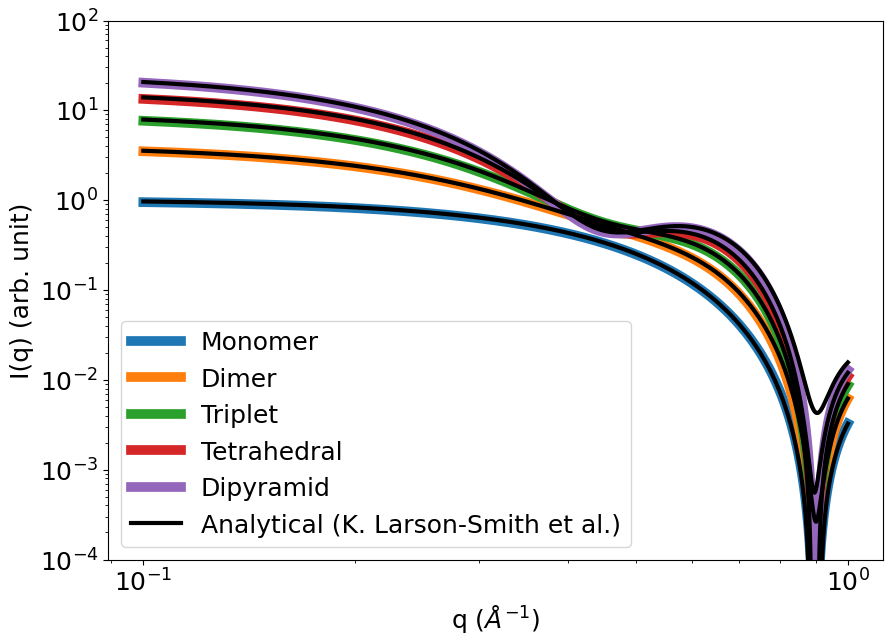

In [23]:
plt.rcParams.update({'font.size': 18})
fig, ax = plt.subplots(figsize=(10,7))
plt.loglog(q, I_monomer, color = 'C0', linewidth=7, label='Monomer')
plt.loglog(q, I_dimer, color = 'C1', linewidth=7, label='Dimer')
plt.loglog(q, I_triplet, color = 'C2', linewidth=7, label='Triplet')
plt.loglog(q, I_tetrahedral, color = 'C3', linewidth=7, label='Tetrahedral')
plt.loglog(q, I_dipyramid, color = 'C4', linewidth=7, label='Dipyramid')

plt.loglog(q, Iq_monomer*1.5e-1, linewidth=3, color='k', label='Analytical (K. Larson-Smith et al.)')
plt.loglog(q, Iq_dimer*1.5e-1, linewidth=3, color='k')
plt.loglog(q, Iq_triplet*1.5e-1, linewidth=3, color='k')
plt.loglog(q, Iq_tetrahedral*1.5e-1, linewidth=3, color='k')
plt.loglog(q, Iq_dipyramid*1.5e-1, linewidth=3, color='k')
plt.ylim([1e-4, 1e2])
plt.legend()
plt.ylabel('I(q) (arb. unit)')
plt.xlabel('q ($\\AA^{-1}$)')

Text(0.5, 0, 'q ($\\AA^{-1}$)')

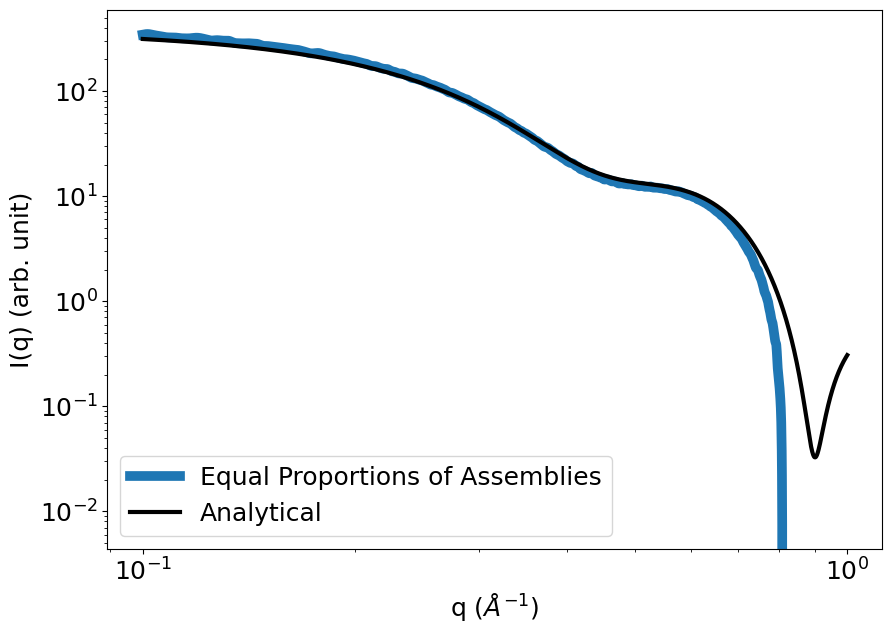

In [24]:
plt.rcParams.update({'font.size': 18})
data = pd.read_csv('../2026-04-21_00-39-36_Polydisperse_Spherical_Assemblies/Intensity.txt', delimiter=' ').values
fig, ax = plt.subplots(figsize=(10,7))
Iq_analytical = Iq_monomer + Iq_dimer + Iq_triplet + Iq_tetrahedral + Iq_dipyramid


plt.loglog(data[:,0], data[:,1]*1.4e-3, color = 'C0', linewidth=7, label='Equal Proportions of Assemblies')
plt.loglog(q, Iq_analytical, linewidth=3, color='k', label='Analytical')

#plt.ylim([1e-4, 1e2])
plt.legend()
plt.ylabel('I(q) (arb. unit)')
plt.xlabel('q ($\\AA^{-1}$)')

In [25]:
data = np.hstack((q.reshape(-1,1), Iq_analytical.reshape(-1,1), np.array([0]*len(q)).reshape(-1,1)))
df = pd.DataFrame(data, columns = ['q','I','dI'])

In [26]:
# df.to_csv('equal_proportions_spherical_assemblies.csv')